In [34]:
# Dépendances du notebook
%pip install openpyxl==3.1.3 pandas==3.0.2 s3fs==2026.3.0 -q

Note: you may need to restart the kernel to use updated packages.


# Imports

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import io
import openpyxl
from openpyxl.drawing.image import Image

# Chargement des données

In [5]:
df = pd.read_csv('../DATA/effectifs.csv', sep=';')
print(df.shape)
print(df.head())

(5216400, 16)
   annee                                         patho_niv1      patho_niv2  \
0   2023  Maladies inflammatoires ou rares ou infection VIH  Maladies rares   
1   2023  Maladies inflammatoires ou rares ou infection VIH  Maladies rares   
2   2023  Maladies inflammatoires ou rares ou infection VIH  Maladies rares   
3   2023  Maladies inflammatoires ou rares ou infection VIH  Maladies rares   
4   2023  Maladies inflammatoires ou rares ou infection VIH  Maladies rares   

      patho_niv3          top cla_age_5  sexe  region dept  Ntop   Npop  prev  \
0  Mucoviscidose  RAR_MUC_IND     95et+     9      28  999   NaN  15550   NaN   
1  Mucoviscidose  RAR_MUC_IND     95et+     9      32   59   NaN   8460   NaN   
2  Mucoviscidose  RAR_MUC_IND     95et+     9      32   60   NaN   2470   NaN   
3  Mucoviscidose  RAR_MUC_IND     95et+     9      32   62   NaN   5010   NaN   
4  Mucoviscidose  RAR_MUC_IND     95et+     9      32   80   NaN   2220   NaN   

  Niveau prioritaire lib

In [15]:
df.dtypes

annee                   int64
patho_niv1                str
patho_niv2                str
patho_niv3                str
top                       str
cla_age_5                 str
sexe                    int64
region                  int64
dept                      str
Ntop                  float64
Npop                    int64
prev                  float64
Niveau prioritaire        str
libelle_classe_age        str
libelle_sexe              str
tri                   float64
dtype: object

# Nettoyage des données

In [ ]:
# Suppression des colonnes non utilisés
df = df.drop(columns=['tri', 'Niveau prioritaire','libelle_classe_age'])


In [13]:
df = df[
    (df["sexe"].astype(str) != "9") &
    (df["dept"].astype(str) != "999") & #On passe les departements en texte car j'ai des valeurs pour la corse en strinf "2A" etcs
    (~df["patho_niv3"].astype(str).str.contains(
        "Total|Pas de pathologie repérée|traitement|maternité", #ces termes sont trop long et rende l'affichage trop petit donc autant les enlevés
        case=False,
        na=False
    ))
]


# DATA VIZ - EXCEL

In [32]:
import pandas as pd
from openpyxl import Workbook
from openpyxl.chart import BarChart, Reference
from openpyxl.utils.dataframe import dataframe_to_rows

df = pd.read_csv("../DATA/effectifs.csv", sep=";")
df.columns = df.columns.str.strip()

df["libelle_sexe"] = df["libelle_sexe"].astype(str).str.strip().str.lower()
df["patho_niv3"] = df["patho_niv3"].astype(str).str.strip()

df["patho_niv3"] = df["patho_niv3"].str.replace(r"\(.*?\)", "", regex=True)
df["patho_niv3"] = df["patho_niv3"].str.replace(
    r"^Autres\s+.*", "Autres pathologies", regex=True, case=False
)
df["patho_niv3"] = df["patho_niv3"].str.replace(r"\s+", " ", regex=True).str.strip()

df_filtre = df[df["libelle_sexe"].isin(["hommes", "femmes"])]
df_filtre = df_filtre[
    ~df_filtre["patho_niv3"].str.contains(
        "Total|Pas de pathologie", na=False, case=False
    )
]

df_pivot = (
    df_filtre.pivot_table(
        index="patho_niv3", columns="libelle_sexe", values="Ntop", aggfunc="sum"
    )
    .fillna(0)
)

df_pct = df_pivot.div(df_pivot.sum(axis=1), axis=0) * 100

wb = Workbook()
ws = wb.active
ws.title = "Data_Pathologies"
ws.views.sheetView[0].showGridLines = True

labels_dynamiques = [str(col).capitalize() for col in df_pct.columns]
df_excel = df_pct.reset_index()
df_excel.columns = ["Pathologies"] + [f"{l} (%)" for l in labels_dynamiques]

for r in dataframe_to_rows(df_excel, index=False, header=True):
    ws.append(r)

max_row = len(df_excel) + 1

chart = BarChart()
chart.type = "bar"
chart.grouping = "stacked"
chart.overlap = 100
chart.title = "Répartition en % par sexe des pathologies"
chart.style = 10

data = Reference(ws, min_col=2, min_row=1, max_col=3, max_row=max_row)
cats = Reference(ws, min_col=1, min_row=2, max_row=max_row)

chart.add_data(data, titles_from_data=True)
chart.set_categories(cats)
chart.y_axis.scaling.orientation = "maxMin"

chart.width = 18
chart.height = 12
ws.add_chart(chart, "E2")

for col in ws.iter_cols(max_col=3):
    max_len = max(len(str(cell.value or "")) for cell in col)
    col_letter = col[0].column_letter
    ws.column_dimensions[col_letter].width = max(max_len + 3, 12)

wb.save("Analyses_Pathologies.xlsx")

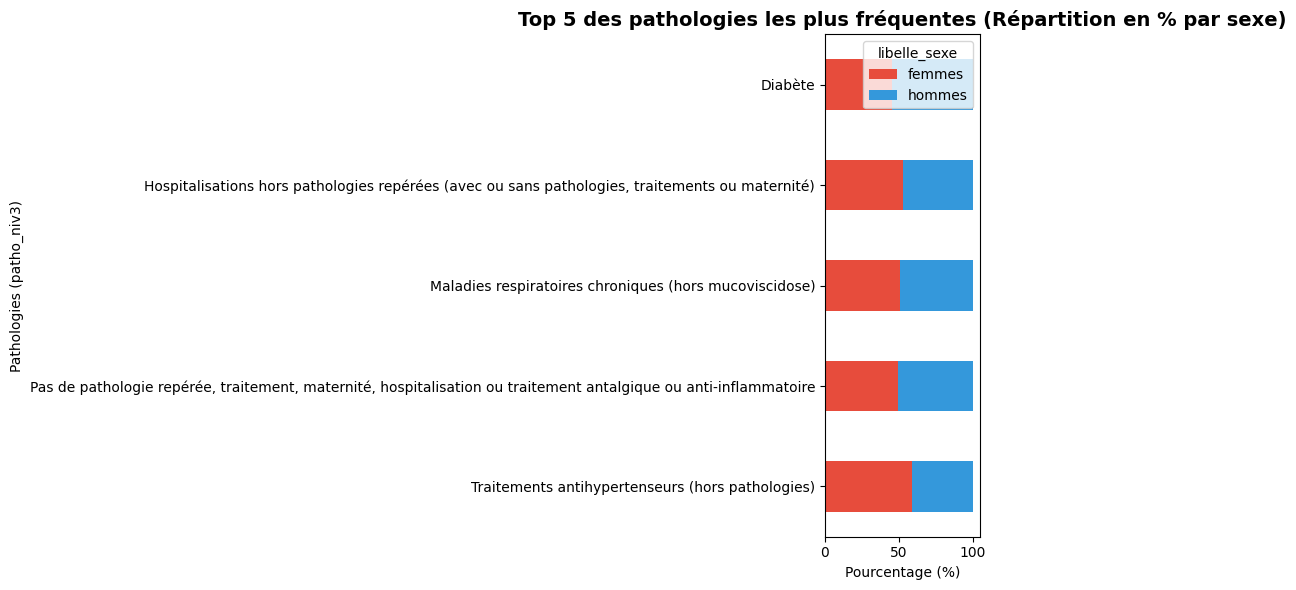

In [33]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('../DATA/effectifs.csv', sep=';')

df.columns = df.columns.str.strip()


df_filtre = df[df['libelle_sexe'].isin(['hommes', 'femmes'])]

df_filtre = df_filtre[~df_filtre['patho_niv3'].str.contains('Total', na=False, case=False)]

top5_maladies = df_filtre.groupby('patho_niv3')['Ntop'].sum().nlargest(5).index

df_top5 = df_filtre[df_filtre['patho_niv3'].isin(top5_maladies)]

df_pivot = df_top5.pivot_table(
    index='patho_niv3', 
    columns='libelle_sexe', 
    values='Ntop', 
    aggfunc='sum'
).fillna(0)

df_pivot = df_pivot.loc[df_pivot.index.intersection(top5_maladies)]

df_pct = df_pivot.div(df_pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 6))
df_pct.plot(kind='barh', stacked=True, color=['#e74c3c', '#3498db'], ax=ax)

ax.invert_yaxis()  
ax.set_title('Top 5 des pathologies les plus fréquentes (Répartition en % par sexe)', fontsize=14, fontweight='bold')
ax.set_xlabel('Pourcentage (%)')
ax.set_ylabel('Pathologies (patho_niv3)')

plt.tight_layout()
plt.show()